In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [4]:
import zipfile

zip_ref = zipfile.ZipFile("/content/drive/MyDrive/Dog_Breed_project/archive.zip")
zip_ref.extractall()
zip_ref.close

<bound method ZipFile.close of <zipfile.ZipFile filename='/content/drive/MyDrive/Dog_Breed_project/archive.zip' mode='r'>>

In [5]:
train_dir = "/content/train"
test_dir = "/content/test"

array([[[ 41,  37,  34],
        [ 47,  43,  40],
        [ 53,  49,  46],
        ...,
        [230, 227, 236],
        [215, 207, 220],
        [206, 195, 209]],

       [[ 39,  35,  32],
        [ 39,  35,  32],
        [ 40,  36,  33],
        ...,
        [218, 216, 227],
        [214, 208, 222],
        [211, 203, 218]],

       [[ 43,  39,  36],
        [ 36,  32,  29],
        [ 34,  30,  27],
        ...,
        [216, 215, 229],
        [221, 217, 234],
        [213, 206, 224]],

       ...,

       [[ 16,  15,  13],
        [ 16,  15,  13],
        [ 18,  19,  14],
        ...,
        [109, 112, 121],
        [129, 132, 141],
        [138, 141, 150]],

       [[ 11,  11,   9],
        [ 10,  12,   9],
        [ 15,  17,  12],
        ...,
        [137, 137, 147],
        [118, 118, 128],
        [106, 106, 116]],

       [[  5,   7,   4],
        [  6,   8,   5],
        [ 11,  16,  10],
        ...,
        [118, 118, 128],
        [115, 113, 124],
        [116, 114, 125]]], dtype=uint8)
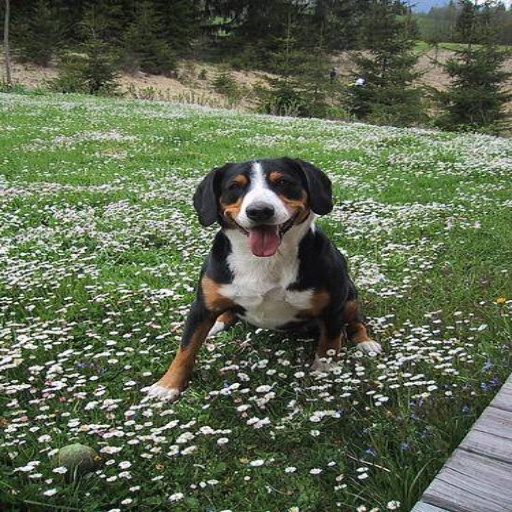

In [6]:
import os
import random
class_names = os.listdir("/content/train")
random_img_path = f"{train_dir}/{random.choice(class_names)}"
random_img = random.choice(os.listdir(random_img_path))
plt.imread(f"{random_img_path}/{random_img}")


In [7]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                 image_size = (224,224),
                                                                 label_mode='categorical')

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                image_size =(224,224),
                                                                label_mode = 'categorical')

Found 8177 files belonging to 120 classes.
Found 2045 files belonging to 120 classes.


(224, 224, 3)


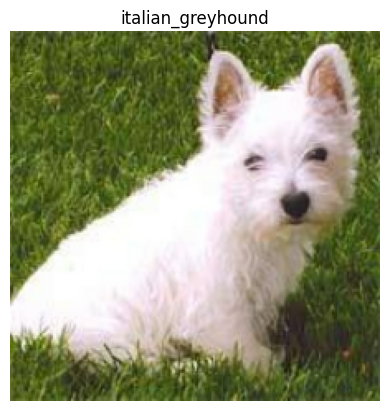

In [8]:
for image,label in train_data:
    plt.imshow(image[0]/255)
    plt.title(class_names[np.argmax(label[0])])
    plt.axis(False)
    print(image[0].shape)
    break

In [9]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
                  layers.RandomFlip('Horizontal'),
                  layers.RandomZoom(0.2),
                  layers.RandomRotation(0.2),
                  layers.RandomHeight(0.2),
                  layers.RandomWidth(0.2),
                  ])

In [10]:
base_model = tf.keras.applications.EfficientNetB3(include_top=False)
base_model.trainable = False

inputs = layers.Input(shape=(224,224,3))
x  = data_augmentation(inputs)
x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(120,activation='softmax')(x)

model_1 = tf.keras.Model(inputs,outputs)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
model_1.compile(loss = tf.keras.losses.CategoricalCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ['accuracy'])

In [15]:
chkpt_dir = "Model_chpkpt/first_chkpt.weights.h5"
model_check = tf.keras.callbacks.ModelCheckpoint(chkpt_dir,
                                                 save_best_only = True,
                                                 save_weights_only = True)

In [18]:
history_1 = model_1.fit(train_data,
                        epochs = 5,
                        validation_data = test_data,
                        validation_steps = int(0.25*len(test_data)),
                        callbacks = [model_check])

Epoch 1/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 50s 196ms/step - accuracy: 0.7752 - loss: 0.7900 - val_accuracy: 0.8594 - val_loss: 0.4478
Epoch 2/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 51s 197ms/step - accuracy: 0.7990 - loss: 0.7146 - val_accuracy: 0.8691 - val_loss: 0.4357
Epoch 3/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 142s 433ms/step - accuracy: 0.8147 - loss: 0.6438 - val_accuracy: 0.8594 - val_loss: 0.4188
Epoch 4/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 52s 203ms/step - accuracy: 0.8297 - loss: 0.5903 - val_accuracy: 0.8770 - val_loss: 0.4279
Epoch 5/5
256/256 ━━━━━━━━━━━━━━━━━━━━ 78s 190ms/step - accuracy: 0.8344 - loss: 0.5722 - val_accuracy: 0.8887 - val_loss: 0.3873


In [21]:
base_model.trainable = True
base_model.layers

[<InputLayer name=input_layer, built=True>,
 <Rescaling name=rescaling, built=True>,
 <Normalization name=normalization, built=True>,
 <Rescaling name=rescaling_1, built=True>,
 <ZeroPadding2D name=stem_conv_pad, built=True>,
 <Conv2D name=stem_conv, built=True>,
 <BatchNormalization name=stem_bn, built=True>,
 <Activation name=stem_activation, built=True>,
 <DepthwiseConv2D name=block1a_dwconv, built=True>,
 <BatchNormalization name=block1a_bn, built=True>,
 <Activation name=block1a_activation, built=True>,
 <GlobalAveragePooling2D name=block1a_se_squeeze, built=True>,
 <Reshape name=block1a_se_reshape, built=True>,
 <Conv2D name=block1a_se_reduce, built=True>,
 <Conv2D name=block1a_se_expand, built=True>,
 <Multiply name=block1a_se_excite, built=True>,
 <Conv2D name=block1a_project_conv, built=True>,
 <BatchNormalization name=block1a_project_bn, built=True>,
 <DepthwiseConv2D name=block1b_dwconv, built=True>,
 <BatchNormalization name=block1b_bn, built=True>,
 <Activation name=block1

In [30]:
for layers in base_model.layers[:-5]:
    layers.trainable = False


In [32]:
for layer in base_model.layers:
    print(f"Layer: {layer.name}, Trainable: {layer.trainable}")

Layer: input_layer, Trainable: False
Layer: rescaling, Trainable: False
Layer: normalization, Trainable: False
Layer: rescaling_1, Trainable: False
Layer: stem_conv_pad, Trainable: False
Layer: stem_conv, Trainable: False
Layer: stem_bn, Trainable: False
Layer: stem_activation, Trainable: False
Layer: block1a_dwconv, Trainable: False
Layer: block1a_bn, Trainable: False
Layer: block1a_activation, Trainable: False
Layer: block1a_se_squeeze, Trainable: False
Layer: block1a_se_reshape, Trainable: False
Layer: block1a_se_reduce, Trainable: False
Layer: block1a_se_expand, Trainable: False
Layer: block1a_se_excite, Trainable: False
Layer: block1a_project_conv, Trainable: False
Layer: block1a_project_bn, Trainable: False
Layer: block1b_dwconv, Trainable: False
Layer: block1b_bn, Trainable: False
Layer: block1b_activation, Trainable: False
Layer: block1b_se_squeeze, Trainable: False
Layer: block1b_se_reshape, Trainable: False
Layer: block1b_se_reduce, Trainable: False
Layer: block1b_se_expand, 

In [35]:
model_1.fit(train_data,
            epochs = 10,
            initial_epoch = history_1.epoch[-1],
            validation_data = test_data,
            validation_steps = int(25*len(test_data)))

Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8448 - loss: 0.5385

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


256/256 ━━━━━━━━━━━━━━━━━━━━ 57s 221ms/step - accuracy: 0.8448 - loss: 0.5385 - val_accuracy: 0.8660 - val_loss: 0.4241
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 53s 207ms/step - accuracy: 0.8556 - loss: 0.4859 - val_accuracy: 0.8689 - val_loss: 0.4207
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 84s 216ms/step - accuracy: 0.8556 - loss: 0.4871 - val_accuracy: 0.8685 - val_loss: 0.4169
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 82s 217ms/step - accuracy: 0.8683 - loss: 0.4451 - val_accuracy: 0.8631 - val_loss: 0.4189
Epoch 9/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 52s 204ms/step - accuracy: 0.8668 - loss: 0.4444 - val_accuracy: 0.8655 - val_loss: 0.4204
Epoch 10/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 84s 213ms/step - accuracy: 0.8766 - loss: 0.4042 - val_accuracy: 0.8680 - val_loss: 0.4194


In [36]:
model_1.save("/content/drive/MyDrive/Dog_Breed_project/model_1.h5")

In [37]:
model_1.evaluate(test_data)

64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.8731 - loss: 0.4112


[0.4194333851337433, 0.8679706454277039]